# Audit of the original genai-smartcity pipeline

Runs the **original dataset** (`model/oldDataset`) through the diagnostics developed for the
walkability replication, so the two pipelines can be compared on the same evidence.

The audit is built as a controlled comparison. The data is held constant and only the
*split* changes:

| Condition | Split | What it isolates |
|---|---|---|
| **A** | random row-level (the original) | performance as originally reported |
| **B** | grouped by near-duplicate | performance once template variants cannot straddle the split |

If A is high and B collapses, the reported numbers came from leakage between near-duplicate
synthetic examples. If both are high, the dataset is genuinely separable — and then the
question becomes whether it is separable by *construct* or by *surface vocabulary*, which the
TF-IDF baseline answers.

Cells 1-7 require **no training** and run in under a minute. Training (cell 8 onward) is
optional and reproduces the original hyperparameters exactly, adding only measurement.

> Two things to know about the original code before reading the results.
> **The positive class is 0**, not 1 (`"GenAI used for smart city application": 0`), which
> inverts every default sklearn binary metric. And the notebook header describes three
> categories while `label_map` defines two — rows labelled *"GenAI mentioned, not used"* are
> silently dropped by the `notna()` filter.

In [19]:
# ============================================================
# 0. Configuration
# ============================================================
import os, re, json, unicodedata, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             matthews_corrcoef, classification_report, confusion_matrix)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# >>> point this at the ORIGINAL dataset <<<
OLD_DIR = "../model/oldDataset"

# the original mapping - positive class is 0
LABEL_MAP  = {"GenAI used for smart city application": 0, "Not related": 1}
POS_ID     = 0
POS_LABEL  = "GenAI used for smart city application"
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

DUP_THRESHOLD = 0.80
print(f"Reading from {OLD_DIR}")
print(f"Positive class id = {POS_ID}  ({POS_LABEL})")

Reading from ../model/oldDataset
Positive class id = 0  (GenAI used for smart city application)


In [20]:
# ============================================================
# 1. Load with provenance (the original concatenated and lost the source)
# ============================================================
SOURCES = ["dataset", "contrastive", "adaptive", "expansion", "real"]
frames = []
for s in SOURCES:
    p = f"{OLD_DIR}/{s}.json"
    if not os.path.exists(p):
        print(f"  [missing] {p}"); continue
    d = pd.DataFrame(json.load(open(p, encoding="utf-8")))
    d["source"] = s
    frames.append(d); print(f"  {s:12s} -> {len(d):4d}")
df = pd.concat(frames, ignore_index=True)

# the third category, silently dropped by the original
raw_labels = df["label"].value_counts()
print(f"\nLabels present in the files:\n{raw_labels.to_string()}")
dropped = df[~df["label"].isin(LABEL_MAP)]
if len(dropped):
    print(f"\n[!] {len(dropped)} rows dropped by label_map "
          f"({dropped['label'].unique().tolist()}) - the original discards these silently.")
df = df[df["label"].isin(LABEL_MAP)].copy()
df["label_id"] = df["label"].map(LABEL_MAP).astype(int)
df["is_real"]  = df["source"] == "real"
print(f"\nUsable: {len(df)} | positives {(df.label_id==POS_ID).sum()} "
      f"| negatives {(df.label_id!=POS_ID).sum()} | real {df.is_real.sum()}")

  dataset      ->  763
  contrastive  ->   30
  adaptive     ->  150
  expansion    ->  195
  real         ->    9

Labels present in the files:
label
GenAI used for smart city application    601
Not related                              546

Usable: 1147 | positives 601 | negatives 546 | real 9


In [21]:
# ============================================================
# 2. Normalisation, exact duplicates and label conflicts
# ============================================================
def norm(t):
    t = unicodedata.normalize("NFKD", str(t)).lower()
    t = re.sub(r"https?://\S+", " ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["norm_text"] = df["text"].map(norm)

dup_exact = len(df) - df["norm_text"].nunique()
print(f"EXACT duplicate texts: {dup_exact} of {len(df)} "
      f"({100*dup_exact/len(df):.1f}%)")
if dup_exact:
    top = df["norm_text"].value_counts().head(3)
    print("Most repeated:")
    for t, n in top.items():
        print(f"   x{n}  {t[:110]}...")

conf = df.groupby("norm_text")["label"].nunique().loc[lambda s: s > 1]
print(f"\nTexts carrying CONFLICTING labels: {len(conf)}")
for t in list(conf.index)[:3]:
    sub = df[df.norm_text == t]
    print(f"   {sub['label'].unique().tolist()} <- {t[:90]}...")

EXACT duplicate texts: 313 of 1147 (27.3%)
Most repeated:
   x6  a diffusion model is used to create synthetic sensor data for training an anomaly detection system in smart gr...
   x6  this paper presents a novel gan based approach for generating realistic urban street scenes aiding in smart ci...
   x6  while gpt appears in the literature the model in this study does not use any generative approach...

Texts carrying CONFLICTING labels: 0


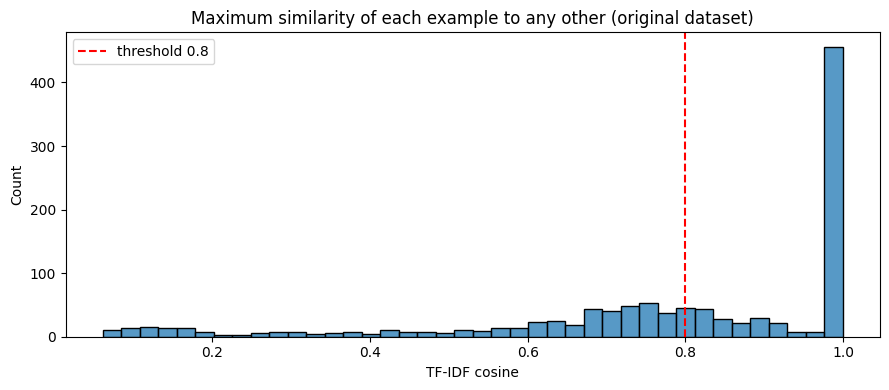

Median maximum similarity: 0.834
Examples with a twin >= 0.8: 642 (56.0%)

689 groups for 1147 examples | largest 28

Largest group (id=440) - these must not straddle a split:
  - A transformer was trained to generate sensor data across varying conditions in smart cities. The generated data was used ...
  - A transformer was trained to create synthetic building designs across varying conditions in smart cities. The generated  ...
  - A VAE was trained to augment pollution maps across varying conditions in smart cities. The generated data was used for t ...


In [22]:
# ============================================================
# 3. Near-duplicate structure - how redundant is the corpus?
# ============================================================
class UF:
    def __init__(s, n): s.p = list(range(n))
    def f(s, x):
        while s.p[x] != x: s.p[x] = s.p[s.p[x]]; x = s.p[x]
        return x
    def u(s, a, b):
        ra, rb = s.f(a), s.f(b)
        if ra != rb: s.p[rb] = ra

vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
X = vec.fit_transform(df["norm_text"])
S = cosine_similarity(X); np.fill_diagonal(S, 0.0)
max_sim = S.max(axis=1)

plt.figure(figsize=(9, 4))
sns.histplot(max_sim, bins=40)
plt.axvline(DUP_THRESHOLD, color="red", ls="--", label=f"threshold {DUP_THRESHOLD}")
plt.title("Maximum similarity of each example to any other (original dataset)")
plt.xlabel("TF-IDF cosine"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Median maximum similarity: {np.median(max_sim):.3f}")
print(f"Examples with a twin >= {DUP_THRESHOLD}: {(max_sim>=DUP_THRESHOLD).sum()} "
      f"({(max_sim>=DUP_THRESHOLD).mean()*100:.1f}%)")

uf = UF(len(df))
ii, jj = np.where(np.triu(S, 1) >= DUP_THRESHOLD)
for a, b in zip(ii, jj): uf.u(int(a), int(b))
_, groups = np.unique([uf.f(i) for i in range(len(df))], return_inverse=True)
df["group_id"] = groups
gs = df.groupby("group_id").size()
print(f"\n{df.group_id.nunique()} groups for {len(df)} examples | largest {gs.max()}")
if gs.max() > 1:
    big = gs.idxmax()
    print(f"\nLargest group (id={big}) - these must not straddle a split:")
    for t in df[df.group_id == big]["text"].head(3): print("  -", t[:120], "...")

## 4. The controlled comparison

Condition **A** reproduces the original split verbatim: `train_test_split` at row level,
stratified by label, 70/15/15, then `diagnostic_test.json` concatenated onto the test set with
no contamination check.

Condition **B** keeps the same data but assigns whole near-duplicate *groups* to a single split.

The leakage audit reports, for each pair of splits, how many identical texts and how many
near-duplicates are shared.

In [23]:
# ============================================================
# 4. Condition A (original split) vs Condition B (grouped split)
# ============================================================
# --- A: exactly as in the original notebook ---
trA, tmp = train_test_split(df, test_size=0.3, stratify=df["label_id"], random_state=SEED)
vaA, teA = train_test_split(tmp, test_size=0.5, stratify=tmp["label_id"], random_state=SEED)

# --- B: grouped ---
def grouped_split(data, sizes=(.7, .15, .15), seed=SEED):
    rng = np.random.default_rng(seed)
    g = (data.groupby("group_id")
             .agg(n=("label_id", "size"), lab=("label_id", lambda s: int(s.mode().iloc[0])))
             .reset_index())
    tr, va, te = [], [], []
    for lab, sub in g.groupby("lab"):
        sub = sub.sample(frac=1.0, random_state=int(rng.integers(1e6)))
        tot = sub["n"].sum(); qv, qt = sizes[1]*tot, sizes[2]*tot; av = at = 0
        for _, r in sub.iterrows():
            if av < qv: va.append(r.group_id); av += r.n
            elif at < qt: te.append(r.group_id); at += r.n
            else: tr.append(r.group_id)
    pick = lambda ids: data[data.group_id.isin(ids)].copy().reset_index(drop=True)
    return pick(tr), pick(va), pick(te)

trB, vaB, teB = grouped_split(df)

def leak(a, b, name):
    ex = len(set(a.norm_text) & set(b.norm_text))
    gr = len(set(a.group_id) & set(b.group_id))
    Sx = cosine_similarity(vec.transform(b.norm_text), vec.transform(a.norm_text))
    near = int((Sx.max(axis=1) >= DUP_THRESHOLD).sum())
    print(f"   {name:12s} identical {ex:4d} | shared groups {gr:4d} | near-dups {near:4d} "
          f"| max sim {Sx.max():.3f}")
    return ex + near

print("CONDITION A - original random row-level split")
la = leak(trA, vaA, "train-val") + leak(trA, teA, "train-test")
print(f"\nCONDITION B - grouped split")
lb = leak(trB, vaB, "train-val") + leak(trB, teB, "train-test")
print(f"\nLeakage signals: A = {la} | B = {lb}")

CONDITION A - original random row-level split
   train-val    identical   57 | shared groups   71 | near-dups   89 | max sim 1.000
   train-test   identical   55 | shared groups   67 | near-dups   88 | max sim 1.000

CONDITION B - grouped split
   train-val    identical    0 | shared groups    0 | near-dups    0 | max sim 0.799
   train-test   identical    0 | shared groups    0 | near-dups    0 | max sim 0.797

Leakage signals: A = 289 | B = 0


In [24]:
# ============================================================
# 5. TF-IDF baseline + permutation test on BOTH conditions
#    No transformer needed: this is what tells you whether the task is
#    separable by surface vocabulary.
# ============================================================
def baseline(tr, ev, y_tr=None, seed=SEED):
    y = tr["label_id"].values if y_tr is None else y_tr
    clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                        LogisticRegression(max_iter=2000, class_weight="balanced",
                                           random_state=seed))
    clf.fit(tr["text"], y)
    p = clf.predict(ev["text"])
    return (accuracy_score(ev.label_id, p),
            f1_score(ev.label_id, p, average="macro", zero_division=0))

rows = []
for name, (tr, va) in [("A - original split", (trA, vaA)), ("B - grouped split", (trB, vaB))]:
    acc, f1m = baseline(tr, va)
    maj = max(va.label_id.mean(), 1 - va.label_id.mean())
    rng = np.random.default_rng(SEED)
    perm = [baseline(tr, va, y_tr=rng.permutation(tr.label_id.values), seed=SEED+k)[0]
            for k in range(10)]
    rows.append({"condition": name, "accuracy": round(acc, 3), "macro_F1": round(f1m, 3),
                 "majority": round(maj, 3), "shuffled_labels": round(float(np.mean(perm)), 3)})
res = pd.DataFrame(rows)
print(res.to_string(index=False))

print("\n--- HOW TO READ ---")
print("accuracy near 1.0  -> a bag-of-words model already solves it: separable by lexicon.")
print("A high, B lower    -> part of the original score came from near-duplicate leakage.")
print("A ~ B, both high   -> no leakage, but the task is still lexically trivial.")
print("shuffled ~ majority-> no structural leakage (the split itself is sound).")

         condition  accuracy  macro_F1  majority  shuffled_labels
A - original split     0.942     0.942     0.523            0.477
 B - grouped split     0.942     0.942     0.532            0.492

--- HOW TO READ ---
accuracy near 1.0  -> a bag-of-words model already solves it: separable by lexicon.
A high, B lower    -> part of the original score came from near-duplicate leakage.
A ~ B, both high   -> no leakage, but the task is still lexically trivial.
shuffled ~ majority-> no structural leakage (the split itself is sound).


In [25]:
# ============================================================
# 6. Which words carry the signal?
#    If the top coefficients are topic words rather than construct words,
#    the classifier is keyed to vocabulary, not to the concept.
# ============================================================
pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                     LogisticRegression(max_iter=2000, class_weight="balanced",
                                        random_state=SEED))
pipe.fit(trB["text"], trB["label_id"])
names = np.array(pipe[0].get_feature_names_out())
coef = pipe[1].coef_[0]
order = np.argsort(coef)
n_top = 20
print(f"Most indicative of class {ID_TO_LABEL[1]}:")
print("   " + ", ".join(names[order[-n_top:]][::-1]))
print(f"\nMost indicative of class {ID_TO_LABEL[0]}:")
print("   " + ", ".join(names[order[:n_top]]))
print("\nIf these are method names and topic nouns rather than markers of *usage*,")
print("the model is discriminating vocabulary, not the underlying construct.")

Most indicative of class Not related:
   the, but, not, the study, rule, rule based, in the, on, study, was, analysis, system for, regression, for automatically, were, mentions, in city, to analyze, clustering, mentions the

Most indicative of class GenAI used for smart city application:
   generate, to generate, synthetic, urban, diffusion, scenarios, generate synthetic, to create, create, diffusion model, vae, realistic, explores, explores the, simulations, synthesize, to synthesize, for, simulation, presents

If these are method names and topic nouns rather than markers of *usage*,
the model is discriminating vocabulary, not the underlying construct.


diagnostic_test.json: 111 examples | positives 56

Contamination of the diagnostic set against the ORIGINAL train+val:
   identical texts: 9 | near-duplicates: 31 | max similarity: 1.000
   -> the original appends this file to the test set without this check.


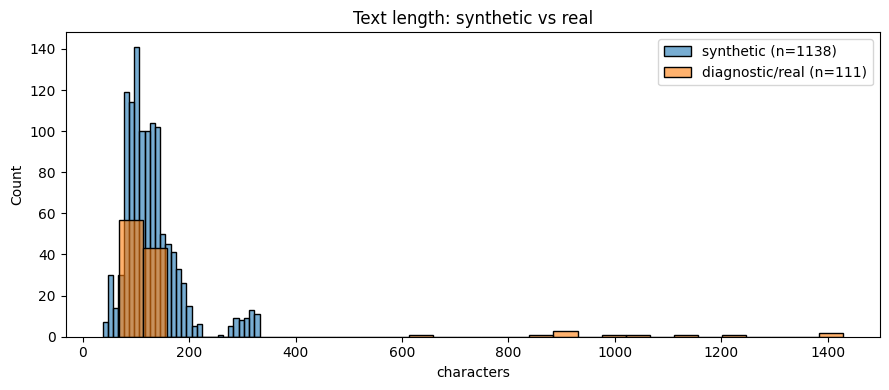

median length -> synthetic 118 | real 112
A large gap is itself a shortcut the model can exploit.

Baseline trained on synthetic -> evaluated on the diagnostic set:
   accuracy 0.973 | macro F1 0.973 | majority 0.505
   Compare against the in-domain figures in cell 5. The drop is the
   synthetic-to-real generalisation gap.


In [26]:
# ============================================================
# 7. Real vs synthetic: is there anything to generalise TO?
# ============================================================
diag_path = f"{OLD_DIR}/diagnostic_test.json"
if os.path.exists(diag_path):
    diag = pd.DataFrame(json.load(open(diag_path, encoding="utf-8")))
    diag = diag[diag["label"].isin(LABEL_MAP)].copy()
    diag["label_id"] = diag["label"].map(LABEL_MAP).astype(int)
    diag["norm_text"] = diag["text"].map(norm)
    print(f"diagnostic_test.json: {len(diag)} examples "
          f"| positives {(diag.label_id==POS_ID).sum()}")

    # contamination against the ORIGINAL training split
    seen = set(trA.norm_text) | set(vaA.norm_text)
    ex = diag.norm_text.isin(seen).sum()
    Sd = cosine_similarity(vec.transform(diag.norm_text),
                           vec.transform(pd.concat([trA, vaA]).norm_text))
    near = int((Sd.max(axis=1) >= DUP_THRESHOLD).sum())
    print(f"\nContamination of the diagnostic set against the ORIGINAL train+val:")
    print(f"   identical texts: {ex} | near-duplicates: {near} "
          f"| max similarity: {Sd.max():.3f}")
    if ex or near:
        print("   -> the original appends this file to the test set without this check.")

    # text-length signature: synthetic vs real
    tl_syn = df[~df.is_real]["text"].str.len()
    tl_real = diag["text"].str.len()
    plt.figure(figsize=(9, 4))
    sns.histplot(tl_syn, bins=30, alpha=.6, label=f"synthetic (n={len(tl_syn)})")
    sns.histplot(tl_real, bins=30, alpha=.6, label=f"diagnostic/real (n={len(tl_real)})")
    plt.title("Text length: synthetic vs real")
    plt.xlabel("characters"); plt.legend(); plt.tight_layout(); plt.show()
    print(f"median length -> synthetic {tl_syn.median():.0f} | real {tl_real.median():.0f}")
    print("A large gap is itself a shortcut the model can exploit.")

    # baseline trained on synthetic, evaluated on real
    acc_r, f1_r = baseline(trB, diag)
    maj_r = max(diag.label_id.mean(), 1 - diag.label_id.mean())
    print(f"\nBaseline trained on synthetic -> evaluated on the diagnostic set:")
    print(f"   accuracy {acc_r:.3f} | macro F1 {f1_r:.3f} | majority {maj_r:.3f}")
    print("   Compare against the in-domain figures in cell 5. The drop is the")
    print("   synthetic-to-real generalisation gap.")
else:
    print(f"{diag_path} not found - skipping.")

## 8. Optional: train with the original hyperparameters

Everything above is measurement without training. This section reproduces the original
configuration exactly — `microsoft/deberta-v3-base`, `max_length=512`, `padding="max_length"`,
8 epochs, `metric_for_best_model="loss"` — and adds only the diagnostics: WSS@95, the threshold
sweep, and the synthetic-versus-real probability histograms.

Run it twice, once per condition, by changing `CONDITION`. The comparison of the two runs is
the result.

Training artifacts will be written to: c:\Users\vinic\Desktop\genai-smartcity\model\output\audit_original_b


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Pos,Precision Pos,Recall Pos,Mcc,Pr Auc
1,0.099600,0.084366,0.913295,0.911291,0.924623,0.859813,1.000000,0.837012,0.852110
2,0.042400,0.070589,0.953757,0.953306,0.957895,0.928571,0.989130,0.908953,0.944482
3,0.000800,0.096926,0.919075,0.918462,0.925532,0.906250,0.945652,0.837921,0.972482
4,0.000600,0.120488,0.936416,0.936203,0.939891,0.945055,0.934783,0.872469,0.965635
5,0.000300,0.097065,0.936416,0.935997,0.941176,0.926316,0.956522,0.872564,0.995751


Model saved to c:\Users\vinic\Desktop\genai-smartcity\model\output\audit_original_b\best_model
This path is separate from ../model/output/best_model, so it will not overwrite the other notebook's model.



=== Post-training metrics (validation) ===
{
  "accuracy": 0.953757225433526,
  "f1_macro": 0.953306342780027,
  "f1_pos": 0.9578947368421052,
  "precision_pos": 0.9285714285714286,
  "recall_pos": 0.9891304347826086,
  "mcc": 0.9089528067323971,
  "pr_auc": 0.9444819701802318
}

=== Post-training metrics (test) ===
{
  "accuracy": 0.926056338028169,
  "f1_macro": 0.9256498161191797,
  "f1_pos": 0.9311475409836065,
  "precision_pos": 0.8987341772151899,
  "recall_pos": 0.9659863945578231,
  "mcc": 0.8541106459558969,
  "pr_auc": 0.9221843564574753
}
                                       precision    recall  f1-score   support

GenAI used for smart city application      0.899     0.966     0.931       147
                          Not related      0.960     0.883     0.920       137

                             accuracy                          0.926       284
                            macro avg      0.930     0.925     0.926       284
                         weighted avg      0.9

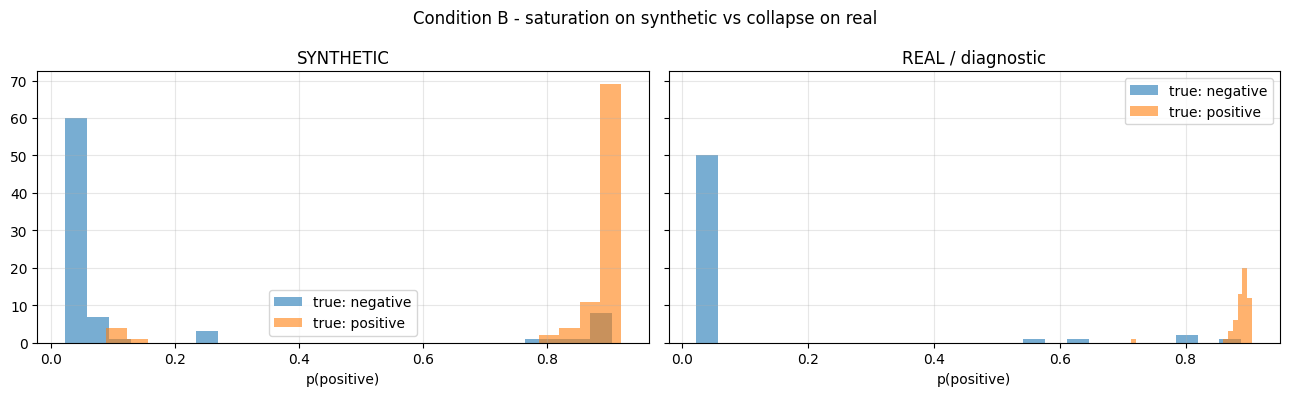

In [27]:
RUN_TRAINING = True      # <- set True to train
CONDITION    = "B"        # "A" = original split, "B" = grouped split

if RUN_TRAINING:
    import torch, torch.nn.functional as F
    from torch.utils.data import Dataset
    from transformers import (AutoModelForSequenceClassification, AutoTokenizer, Trainer,
                              TrainingArguments, EarlyStoppingCallback,
                              DataCollatorWithPadding, set_seed)
    from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                                 matthews_corrcoef, classification_report, confusion_matrix,
                                 average_precision_score)
    set_seed(SEED)
    tr, va, te = (trA, vaA, teA) if CONDITION == "A" else (trB, vaB, teB)
    if os.path.exists(diag_path):
        te = pd.concat([te, diag[te.columns.intersection(diag.columns)]], ignore_index=True)

    MODEL = "microsoft/deberta-v3-base"; MAX_LEN = 512
    AUDIT_OUTPUT_DIR = os.path.abspath(os.path.join("..", "model", "output", f"audit_original_{CONDITION.lower()}"))
    os.makedirs(AUDIT_OUTPUT_DIR, exist_ok=True)
    print(f"Training artifacts will be written to: {AUDIT_OUTPUT_DIR}")
    tok = AutoTokenizer.from_pretrained(MODEL, use_fast=True)

    class DS(Dataset):
        def __init__(s, t, l): s.t, s.l = list(t), list(l)
        def __len__(s): return len(s.t)
        def __getitem__(s, i):
            e = tok(s.t[i], truncation=True, max_length=MAX_LEN)
            e["labels"] = int(s.l[i]); return e

    class Focal(Trainer):
        def __init__(s, *a, gamma=2.0, **k): super().__init__(*a, **k); s.g = gamma
        def compute_loss(s, model, inputs, return_outputs=False, num_items_in_batch=None):
            y = inputs["loss_labels"] if "loss_labels" in inputs else inputs["labels"]
            out = model(**{k: v for k, v in inputs.items() if k != "labels"})
            lp = F.log_softmax(out.logits, -1).gather(1, y.unsqueeze(1)).squeeze(1)
            loss = -(((1 - lp.exp()) ** s.g) * lp).mean()
            return (loss, out) if return_outputs else loss

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL, num_labels=2, id2label=ID_TO_LABEL, label2id=LABEL_MAP)
    args = TrainingArguments(output_dir=AUDIT_OUTPUT_DIR, num_train_epochs=8,
        per_device_train_batch_size=8, per_device_eval_batch_size=16, learning_rate=2e-5,
        weight_decay=0.05, warmup_ratio=0.1, eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=1, load_best_model_at_end=True, metric_for_best_model="loss",
        greater_is_better=False, report_to="none", seed=SEED,
        fp16=torch.cuda.is_available(), logging_steps=10)

    def metrics(ep):
        lg, y = ep; pr = lg.argmax(-1)
        probs = torch.softmax(torch.tensor(lg), dim=-1).numpy()
        preds = probs.argmax(axis=1)
        out = {"accuracy": accuracy_score(y, preds),
               "f1_macro": f1_score(y, preds, average="macro", zero_division=0),
               "f1_pos": f1_score(y, preds, pos_label=POS_ID, zero_division=0),
               "precision_pos": precision_score(y, preds, pos_label=POS_ID, zero_division=0),
               "recall_pos": recall_score(y, preds, pos_label=POS_ID, zero_division=0),
               "mcc": matthews_corrcoef(y, preds)}
        if len(np.unique(y)) > 1:
            out["pr_auc"] = average_precision_score((y == POS_ID).astype(int), probs[:, POS_ID])
        return out

    t = Focal(model=model, args=args, train_dataset=DS(tr.text, tr.label_id),
              eval_dataset=DS(va.text, va.label_id),
              data_collator=DataCollatorWithPadding(tok, pad_to_multiple_of=8),
              compute_metrics=metrics,
              callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], gamma=2.0)
    t.train()

    best_model_dir = os.path.join(AUDIT_OUTPUT_DIR, "best_model")
    os.makedirs(best_model_dir, exist_ok=True)
    t.save_model(best_model_dir)
    tok.save_pretrained(best_model_dir)
    print(f"Model saved to {best_model_dir}")
    print("This path is separate from ../model/output/best_model, so it will not overwrite the other notebook's model.")

    def summarize_metrics(labels, probs):
        preds = probs.argmax(1)
        out = {"accuracy": accuracy_score(labels, preds),
               "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
               "f1_pos": f1_score(labels, preds, pos_label=POS_ID, zero_division=0),
               "precision_pos": precision_score(labels, preds, pos_label=POS_ID, zero_division=0),
               "recall_pos": recall_score(labels, preds, pos_label=POS_ID, zero_division=0),
               "mcc": matthews_corrcoef(labels, preds)}
        if len(np.unique(labels)) > 1:
            out["pr_auc"] = average_precision_score((labels == POS_ID).astype(int), probs[:, POS_ID])
        return out, preds

    val_out = t.predict(DS(va.text, va.label_id))
    test_out = t.predict(DS(te.text, te.label_id))
    val_probs = torch.softmax(torch.tensor(val_out.predictions), -1).numpy()
    test_probs = torch.softmax(torch.tensor(test_out.predictions), -1).numpy()
    val_metrics, _ = summarize_metrics(val_out.label_ids, val_probs)
    test_metrics, test_preds = summarize_metrics(test_out.label_ids, test_probs)

    print("\n=== Post-training metrics (validation) ===")
    print(json.dumps(val_metrics, indent=2))
    print("\n=== Post-training metrics (test) ===")
    print(json.dumps(test_metrics, indent=2))

    y = (test_out.label_ids == POS_ID).astype(int)
    p_pos = test_probs[:, POS_ID]

    print(classification_report(test_out.label_ids, test_preds,
          target_names=[ID_TO_LABEL[0], ID_TO_LABEL[1]], digits=3, zero_division=0))

    def wss(y, s, target=0.95):
        best = None
        for thr in np.linspace(.001, .999, 999):
            pr = (s >= thr).astype(int); r = recall_score(y, pr, zero_division=0)
            if r >= target:
                w = (1 - pr.mean()) - (1 - r)
                if best is None or w > best[0]: best = (w, thr, r, pr.mean())
        return best
    for tg in (.95, .90):
        r = wss(y, p_pos, tg)
        print(f"WSS@{int(tg*100)}: " + ("UNREACHABLE" if r is None
              else f"{r[0]*100:.1f}% (thr {r[1]:.3f}, recall {r[2]:.3f})"))

    is_real = te["source"].eq("real").values if "source" in te else np.zeros(len(te), bool)
    is_diag = ~te.index.isin(range(len(te) - len(diag))) if os.path.exists(diag_path) else is_real
    fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    for a, m, ttl in [(ax[0], ~is_diag, "SYNTHETIC"), (ax[1], is_diag, "REAL / diagnostic")]:
        if m.sum() == 0: a.set_title(f"{ttl} (none)"); continue
        a.hist(p_pos[m][y[m] == 0], bins=25, alpha=.6, label="true: negative")
        a.hist(p_pos[m][y[m] == 1], bins=25, alpha=.6, label="true: positive")
        a.set_title(ttl); a.set_xlabel("p(positive)"); a.legend(); a.grid(alpha=.3)
    plt.suptitle(f"Condition {CONDITION} - saturation on synthetic vs collapse on real")
    plt.tight_layout(); plt.show()
else:
    print("RUN_TRAINING=False - measurement-only audit complete.")


## What the comparison establishes

Fill this table from the outputs above and from the walkability replication, and it becomes a
methods subsection:

| | genai-smartcity (original data) | walkability (this project) |
|---|---|---|
| Exact duplicates | cell 2 | 0 |
| Near-duplicate rate at 0.80 | cell 3 | cell 3 of the training notebook |
| Leakage, original split | cell 4 (A) | — |
| Leakage, grouped split | cell 4 (B) | 0 (asserted) |
| TF-IDF baseline | cell 5 | 0.937 |
| Permutation test | cell 5 | passed (0.491 vs 0.503) |
| Synthetic-to-real drop | cell 7 | F1 0.93 -> recall 0.245 |
| WSS@95 | cell 8 | 12.4% |

Two readings are possible and they lead to different papers.

If the original shows the same pattern — high in-domain scores, sharp drop on real abstracts —
then synthetic-only training does not transfer *in general*, and the replication is evidence
about the method rather than about one dataset.

If the original transfers and the walkability replication does not, the difference lies in the
task: distinguishing "generative model used versus merely mentioned" is largely a lexical
decision, while "sensor measures a walkability dimension" requires the inferential-target and
instrument-versus-stimulus judgements that no surface pattern encodes.

Either way, report it as a boundary condition of the method, not as a defect of the original
work — the original simply did not have a real-abstract diagnostic set with which to see it.

Optimal temperature (fitted on VALIDATION): 0.7500 | NLL 0.1584

=== Classification report (TEST) - THRESHOLD 0.5, provisional ===
    (the operational number is in the next cells, with the tuned threshold)

                                       precision    recall  f1-score   support

GenAI used for smart city application      0.899     0.966     0.931       147
                          Not related      0.960     0.883     0.920       137

                             accuracy                          0.926       284
                            macro avg      0.930     0.925     0.926       284
                         weighted avg      0.928     0.926     0.926       284



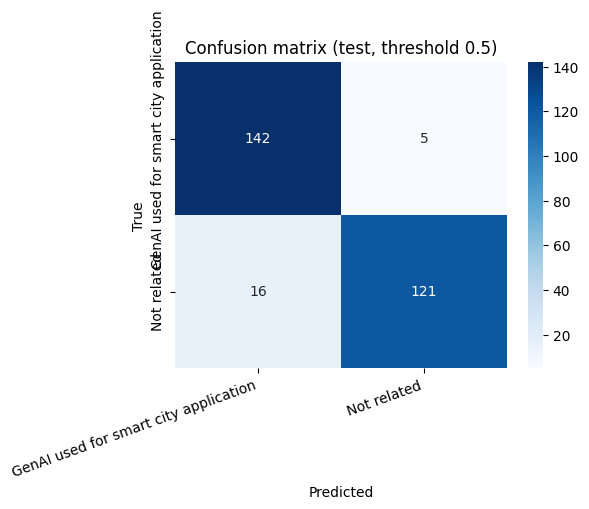

In [29]:
# ============================================================
# 12. Temperature calibration - using the computed variable
# ============================================================
def fit_temperature(logits, labels, grid=np.linspace(0.5, 5.0, 181)):
    lt = torch.tensor(logits, dtype=torch.float32)
    ly = torch.tensor(labels, dtype=torch.long)
    nlls = [F.cross_entropy(lt / float(T), ly).item() for T in grid]
    return float(grid[int(np.argmin(nlls))]), float(np.min(nlls))

train_df = tr.copy().reset_index(drop=True)
val_df = va.copy().reset_index(drop=True)
test_df = te.copy().reset_index(drop=True)

if "val_out" not in locals():
    val_out = t.predict(DS(val_df["text"], val_df["label_id"]))
if "test_out" not in locals():
    test_out = t.predict(DS(test_df["text"], test_df["label_id"]))

val_logits = np.asarray(val_out.predictions)
test_logits = np.asarray(test_out.predictions)
val_labels = np.asarray(val_out.label_ids)
test_labels = np.asarray(test_out.label_ids)

temperature, nll = fit_temperature(val_logits, val_labels)
print(f"Optimal temperature (fitted on VALIDATION): {temperature:.4f} | NLL {nll:.4f}")

val_probs = torch.softmax(torch.tensor(val_logits) / temperature, dim=-1).numpy()
test_probs = torch.softmax(torch.tensor(test_logits) / temperature, dim=-1).numpy()
test_preds = test_probs.argmax(axis=1)

print("\n=== Classification report (TEST) - THRESHOLD 0.5, provisional ===")
print("    (the operational number is in the next cells, with the tuned threshold)\n")
names = [ID_TO_LABEL[i] for i in sorted(ID_TO_LABEL)]
print(classification_report(test_labels, test_preds, target_names=names,
                            digits=3, zero_division=0))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix (test, threshold 0.5)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

In [30]:
# ============================================================
# 13. Bootstrap confidence intervals
#     With ~30 test examples, an isolated point ("F1 = 1.00") means
#     nothing without uncertainty. Report the CI in the paper.
# ============================================================
def bootstrap_ci(y_true, y_pred, metric, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric(y_true[idx], y_pred[idx]))
    return np.mean(vals), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

for label, fn in [
    ("Macro F1",       lambda a, b: f1_score(a, b, average="macro", zero_division=0)),
    ("Recall (pos)",   lambda a, b: recall_score(a, b, pos_label=POS_ID, zero_division=0)),
    ("Precision (pos)", lambda a, b: precision_score(a, b, pos_label=POS_ID, zero_division=0)),
]:
    m, lo, hi = bootstrap_ci(test_labels, test_preds, fn)
    print(f"{label:17s}: {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

Macro F1         : 0.926  95% CI [0.894, 0.954]
Recall (pos)     : 0.967  95% CI [0.935, 0.993]
Precision (pos)  : 0.899  95% CI [0.852, 0.941]


## 14. Threshold selection for screening

For a systematic review, erring towards a false positive is cheap (you read one more abstract) and
erring towards a false negative is expensive (you lose an eligible article). The default `argmax`
(threshold 0.5) is not the right choice: tune the threshold on **validation** to guarantee high
recall and report the resulting precision.

Chosen threshold: 0.85 (val recall 0.989, precision 0.938)

On TEST with that threshold -> recall 0.959 | precision 0.910


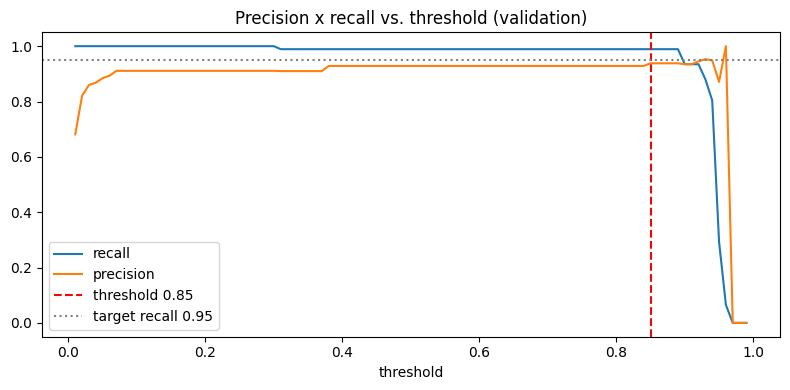

In [31]:
# ============================================================
# 14. Operating threshold tuned on VALIDATION, applied to TEST
# ============================================================
val_probs = torch.softmax(torch.tensor(val_out.predictions) / temperature, dim=-1).numpy()[:, POS_ID]
val_y = (val_out.label_ids == POS_ID).astype(int)

TARGET_RECALL = 0.95
rows = []
for thr in np.linspace(0.01, 0.99, 99):
    p = (val_probs >= thr).astype(int)
    rows.append({"thr": thr,
                 "recall": recall_score(val_y, p, zero_division=0),
                 "precision": precision_score(val_y, p, zero_division=0)})
sweep = pd.DataFrame(rows)
ok = sweep[sweep["recall"] >= TARGET_RECALL]
chosen = ok.sort_values("precision", ascending=False).iloc[0] if len(ok) else sweep.iloc[49]
print(f"Chosen threshold: {chosen['thr']:.2f} "
      f"(val recall {chosen['recall']:.3f}, precision {chosen['precision']:.3f})")

test_pos = test_probs[:, POS_ID]
test_thr_preds = (test_pos >= chosen["thr"]).astype(int)
ty = (test_labels == POS_ID).astype(int)
print(f"\nOn TEST with that threshold -> recall {recall_score(ty, test_thr_preds, zero_division=0):.3f} "
      f"| precision {precision_score(ty, test_thr_preds, zero_division=0):.3f}")

plt.figure(figsize=(8, 4))
plt.plot(sweep["thr"], sweep["recall"], label="recall")
plt.plot(sweep["thr"], sweep["precision"], label="precision")
plt.axvline(chosen["thr"], color="red", ls="--", label=f"threshold {chosen['thr']:.2f}")
plt.axhline(TARGET_RECALL, color="gray", ls=":", label=f"target recall {TARGET_RECALL}")
plt.xlabel("threshold"); plt.legend(); plt.title("Precision x recall vs. threshold (validation)")
plt.tight_layout(); plt.show()

### How to choose `TARGET_RECALL`

The cell below shows, **on real abstracts**, how much screening effort you save and how many
eligible articles you lose at each threshold. Common references in ML-assisted systematic review:
recall >= 0.95 is conservative and widely accepted; 0.90 is often accepted when combined with
snowballing; below that it is hard to defend.

If the `pct_discarded` column is small at the recall you want, the model is not discriminating
well - and then the problem is the data, not the threshold.

[warning] no 'diagnostic' examples in test - using the whole test set.
Diagnostic set: 284 real abstracts (51.8% positive)

 threshold  recall  precision    F1  pct_to_read  pct_discarded  eligible_missed
      0.05   0.973      0.877 0.923         57.4           42.6                4
      0.10   0.966      0.882 0.922         56.7           43.3                5
      0.15   0.966      0.882 0.922         56.7           43.3                5
      0.20   0.966      0.899 0.931         55.6           44.4                5
      0.25   0.966      0.899 0.931         55.6           44.4                5
      0.30   0.966      0.899 0.931         55.6           44.4                5
      0.35   0.966      0.899 0.931         55.6           44.4                5
      0.40   0.966      0.899 0.931         55.6           44.4                5
      0.45   0.966      0.899 0.931         55.6           44.4                5
      0.50   0.966      0.899 0.931         55.6           44.4   

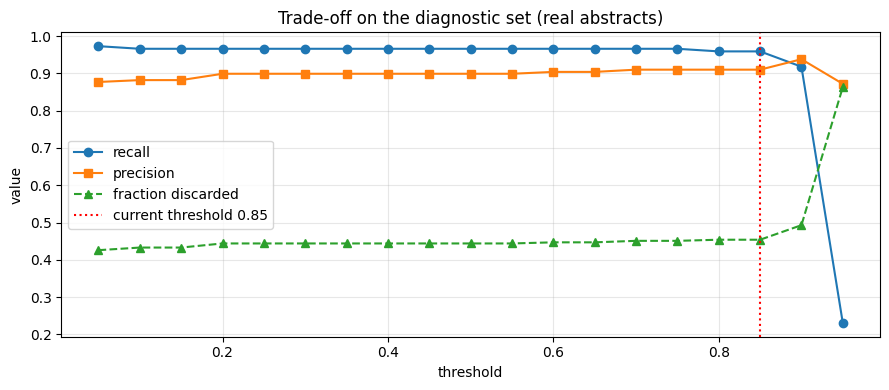

In [32]:
# ============================================================
# 14b. THRESHOLD TRADE-OFF: recall vs. screening workload
#      This is the table that decides TARGET_RECALL - and that goes in the protocol.
# ============================================================
diag_mask = (test_df["source"] == "diagnostic").values
if diag_mask.sum() == 0:
    print("[warning] no 'diagnostic' examples in test - using the whole test set.")
    diag_mask = np.ones(len(test_df), dtype=bool)

d_p = test_probs[diag_mask, POS_ID]
d_y = (test_labels[diag_mask] == POS_ID).astype(int)
print(f"Diagnostic set: {len(d_y)} real abstracts ({d_y.mean()*100:.1f}% positive)\n")

rows = []
for tr in np.linspace(0.05, 0.95, 19):
    p = (d_p >= tr).astype(int)
    rows.append({
        "threshold": round(tr, 2),
        "recall": round(recall_score(d_y, p, zero_division=0), 3),
        "precision": round(precision_score(d_y, p, zero_division=0), 3),
        "F1": round(f1_score(d_y, p, zero_division=0), 3),
        "pct_to_read": round(100 * p.mean(), 1),
        "pct_discarded": round(100 * (1 - p.mean()), 1),
        "eligible_missed": int(((d_y == 1) & (p == 0)).sum()),
    })
sweep_diag = pd.DataFrame(rows)
print(sweep_diag.to_string(index=False))

print("\n--- HOW TO READ ---")
print("'pct_discarded' is the real saving in screening workload.")
print("'eligible_missed' is the cost. Choose the threshold by looking at both columns.")

thr_now = float(chosen["thr"])
p_now = (d_p >= thr_now).astype(int)
print(f"\nCurrent threshold = {thr_now:.2f} (TARGET_RECALL={TARGET_RECALL})")
print(f"  recall {recall_score(d_y, p_now, zero_division=0):.3f} | "
      f"precision {precision_score(d_y, p_now, zero_division=0):.3f} | "
      f"discards {100*(1-p_now.mean()):.1f}% of the corpus | "
      f"misses {int(((d_y==1)&(p_now==0)).sum())} eligible")

print("\n=== Confusion matrix on the DIAGNOSTIC set (operating threshold) ===")
cmd = confusion_matrix(d_y, p_now)
print(pd.DataFrame(cmd,
      index=["true: Not related", "true: Sensing"],
      columns=["pred: Not related", "pred: Sensing"]).to_string())

plt.figure(figsize=(9, 4))
plt.plot(sweep_diag["threshold"], sweep_diag["recall"], marker="o", label="recall")
plt.plot(sweep_diag["threshold"], sweep_diag["precision"], marker="s", label="precision")
plt.plot(sweep_diag["threshold"], sweep_diag["pct_discarded"] / 100,
         marker="^", ls="--", label="fraction discarded")
plt.axvline(thr_now, color="red", ls=":", label=f"current threshold {thr_now:.2f}")
plt.xlabel("threshold"); plt.ylabel("value")
plt.title("Trade-off on the diagnostic set (real abstracts)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### WSS@95 - the number the field expects

`pct_discarded` alone overstates the benefit, because a classifier that discards a lot
while missing eligible articles is not saving work, it is corrupting the review. WSS
corrects the saving by the recall actually achieved, and is the metric used across the
technology-assisted review literature.

The histograms below are the fastest way to see whether the model generalises: compare
the shape of the probability distribution on synthetic versus real examples.

In [33]:
# ============================================================
# 14c. WSS@95 and probability-distribution diagnostic
#      WSS (Work Saved over Sampling) is the standard metric in the
#      technology-assisted review literature (Cohen et al. 2006;
#      O'Mara-Eves et al. 2015). Published reviews report savings of
#      30-70% at 95% recall. Report WSS@95 in the paper.
# ============================================================
def wss_at_recall(y, p, target=0.95):
    """Work Saved over Sampling at a target recall.
    WSS@R = (fraction not screened) - (1 - recall achieved)."""
    best = None
    for thr in np.linspace(0.001, 0.999, 999):
        pred = (p >= thr).astype(int)
        rec = recall_score(y, pred, zero_division=0)
        if rec >= target:
            wss = (1 - pred.mean()) - (1 - rec)
            if best is None or wss > best[0]:
                best = (wss, thr, rec, pred.mean())
    return best

for target in (0.95, 0.90, 0.85):
    res = wss_at_recall(d_y, d_p, target)
    if res is None:
        print(f"WSS@{int(target*100)}: recall {target} is UNREACHABLE at any threshold.")
        continue
    wss, thr, rec, frac = res
    print(f"WSS@{int(target*100)}: {wss*100:5.1f}%  "
          f"(threshold {thr:.3f}, recall {rec:.3f}, screens {frac*100:.1f}% of corpus)")

print("\nLiterature benchmark (O'Mara-Eves et al. 2015): 30-70% workload saving")
print("at ~95% recall. Below ~20% the classifier is not earning its place.")

# ---- probability distributions: synthetic vs real ----
syn_mask = (~test_df["is_real"]).values
fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for a, mask, title in [(ax[0], syn_mask, "SYNTHETIC test examples"),
                       (ax[1], test_df["is_real"].values, "REAL abstracts")]:
    if mask.sum() == 0:
        a.set_title(f"{title} (none)"); continue
    pp = test_probs[mask, POS_ID]
    yy = (test_labels[mask] == POS_ID).astype(int)
    a.hist(pp[yy == 0], bins=25, alpha=.6, label="true: Not related")
    a.hist(pp[yy == 1], bins=25, alpha=.6, label="true: Sensing")
    a.set_title(title); a.set_xlabel("p_positive"); a.legend(); a.grid(alpha=.3)
ax[0].set_ylabel("count")
plt.suptitle("If the two panels look different, the model learned text style, not the construct")
plt.tight_layout(); plt.show()

print("\n--- HOW TO READ THE HISTOGRAMS ---")
print("Healthy: both panels show the two classes separated, with mass at both ends.")
print("Memorisation: synthetic panel saturated at 0 and 1 (no uncertainty), real")
print("panel squashed into a narrow band near 0 - the model does not recognise")
print("real text and defaults to 'negative'. That is what produces a recall cliff")
print("between thresholds 0.05 and 0.10.")

# separation statistic
for mask, name in [(syn_mask, "synthetic"), (test_df["is_real"].values, "real")]:
    if mask.sum() == 0: continue
    pp = test_probs[mask, POS_ID]; yy = (test_labels[mask] == POS_ID).astype(int)
    if len(np.unique(yy)) < 2: continue
    print(f"\n{name:10s}: mean p_pos | positives {pp[yy==1].mean():.3f} "
          f"| negatives {pp[yy==0].mean():.3f} "
          f"| separation {pp[yy==1].mean()-pp[yy==0].mean():.3f}")
print("\nSeparation below ~0.20 on real abstracts means no threshold will help.")


WSS@95:  42.1%  (threshold 0.873, recall 0.952, screens 53.2% of corpus)
WSS@90:  42.1%  (threshold 0.877, recall 0.946, screens 52.5% of corpus)
WSS@85:  42.1%  (threshold 0.877, recall 0.946, screens 52.5% of corpus)

Literature benchmark (O'Mara-Eves et al. 2015): 30-70% workload saving
at ~95% recall. Below ~20% the classifier is not earning its place.


TypeError: bad operand type for unary ~: 'float'

## 15. Grouped cross-validation - the estimator you should report

With ~180 examples, a single 15% test split carries enormous uncertainty. `StratifiedGroupKFold`
respects the near-duplicate groups **and** uses the whole dataset for evaluation across folds. Run
this for the final numbers in the paper (it is expensive: 5 training runs).

In [ ]:
# ============================================================
# 15. StratifiedGroupKFold (optional - enable when reporting)
# ============================================================
RUN_CV = False   # <- set to True when generating the final numbers
N_FOLDS = 5

if RUN_CV:
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_metrics = []
    for fold, (tr_i, te_i) in enumerate(sgkf.split(df, df["label_id"], groups=df["group_id"])):
        print(f"\n===== Fold {fold+1}/{N_FOLDS} =====")
        tr_fold = df.iloc[tr_i].reset_index(drop=True)
        te_fold = df.iloc[te_i].reset_index(drop=True)
        # inner sub-split for validation (also group-wise)
        inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        i_tr, i_va = next(inner.split(tr_fold, tr_fold["label_id"], groups=tr_fold["group_id"]))
        tr2, va2 = tr_fold.iloc[i_tr], tr_fold.iloc[i_va]

        m = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(LABEL_MAP),
            id2label=ID_TO_LABEL, label2id=LABEL_MAP,
            hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1)
        import copy
        args_f = copy.deepcopy(training_args)   # to_dict() breaks across versions
        args_f.output_dir = f"{OUTPUT_DIR}/fold{fold}"
        c = tr2["label_id"].value_counts().sort_index().values.astype(float)
        t = FocalLossTrainer(
            model=m, args=args_f,
            train_dataset=TextClsDataset(tr2["text"], tr2["label_id"], tokenizer),
            eval_dataset=TextClsDataset(va2["text"], va2["label_id"], tokenizer),
            data_collator=data_collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
            gamma=2.0, alpha=torch.tensor(c.sum() / (len(c) * c), dtype=torch.float))
        t.train()
        r = t.evaluate(TextClsDataset(te_fold["text"], te_fold["label_id"], tokenizer))
        print({k: round(v, 3) for k, v in r.items() if k.startswith("eval_")})
        fold_metrics.append(r)

    cv = pd.DataFrame(fold_metrics)
    print("\n===== Cross-validation summary =====")
    for c_ in ["eval_f1_macro", "eval_recall_pos", "eval_precision_pos", "eval_mcc"]:
        if c_ in cv:
            print(f"{c_:22s}: {cv[c_].mean():.3f} +/- {cv[c_].std():.3f}")
else:
    print("RUN_CV=False - skipping cross-validation.")

RUN_CV=False - skipping cross-validation.


In [ ]:
# ============================================================
# 16. Error analysis
# ============================================================
results_df = test_df[["text", "label", "label_id", "source"]].copy().reset_index(drop=True)
results_df["pred_id"]    = test_thr_preds   # CORRECTED: uses the operating threshold, not argmax
results_df["pred_label"] = results_df["pred_id"].map(ID_TO_LABEL)
results_df["correct"]    = results_df["label_id"] == results_df["pred_id"]
results_df["confidence"] = test_probs.max(axis=1)     # CORRECTED: calibrated probabilities
results_df["p_pos"]      = test_probs[:, POS_ID]

mis = results_df[~results_df["correct"]]
print(f"Errors: {len(mis)} of {len(results_df)}")
for _, r in mis.head(8).iterrows():
    print(f"\n[{r['source']}] true={r['label']} | predicted={r['pred_label']} "
          f"(conf {r['confidence']:.3f})")
    print("  ", r["text"][:200], "...")

# performance by example origin: the column that matters is 'real'/'diagnostic'
print("\nAccuracy by example origin:")
print(results_df.groupby("source")["correct"].agg(["mean", "count"]).round(3))

# lowest-confidence cases = candidates for manual review
print("\nLowest confidence (review manually):")
for _, r in results_df.nsmallest(5, "confidence").iterrows():
    print(f"  {r['confidence']:.3f} | true={r['label']} | predicted={r['pred_label']}")

Errors: 80 of 316

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.939)
   From prediction to explanation: A machine learning and causal mediation framework for roadway crash risk with connected vehicle data. Traditional safety analysis often relies on static roadway attribu ...

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.938)
   Walkability under Climate Pressure: Application to Three UNESCO World Heritage Cities in Central Spain. Walkability is a modern concept that has become important in recent years due to the doubtless e ...

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.907)
   Measuring Streetscape Features with High-Density Aerial Light Detection and Ranging. This study investigates the feasibility of extracting streetscape features from high-density United States Geologic ...

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.710)
   From synthetic navigati

In [ ]:
# ============================================================
# 17. Inference + deployment artefacts (consistent max_length)
# ============================================================
def predict(texts, model=None, tok=None, temp=None, threshold=None):
    model = model or trainer.model
    tok = tok or tokenizer
    temp = temperature if temp is None else temp
    threshold = float(chosen["thr"]) if threshold is None else threshold
    single = isinstance(texts, str)
    texts = [texts] if single else list(texts)

    model.eval().to(device)
    enc = tok(texts, truncation=True, padding=True,
              max_length=MAX_LEN, return_tensors="pt").to(device)   # SAME MAX_LEN as training
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits / temp, dim=-1).cpu().numpy()

    out = [{"predicted_label": ID_TO_LABEL[POS_ID] if p[POS_ID] >= threshold
                               else ID_TO_LABEL[1 - POS_ID],
            "p_positive": float(p[POS_ID]),
            "probabilities": {ID_TO_LABEL[i]: float(v) for i, v in enumerate(p)}}
           for p in probs]
    return out[0] if single else out

json.dump({
    "model_name": MODEL_NAME,
    "num_labels": len(LABEL_MAP),
    "id2label": {str(k): v for k, v in ID_TO_LABEL.items()},
    "label2id": LABEL_MAP,
    "max_length": MAX_LEN,
    "temperature": float(temperature),
    "decision_threshold": float(chosen["thr"]),
    "positive_class_id": POS_ID,
}, open(f"{OUTPUT_DIR}/model_config.json", "w"), indent=2)
print(f"Config saved to {OUTPUT_DIR}/model_config.json")

# splits persisted for auditing / reproducibility in the paper
for name, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    d.drop(columns=["norm_text"], errors="ignore").to_json(
        f"{DATA_DIR}/{name}.json", orient="records", indent=2, force_ascii=False)
print(f"Splits saved to {DATA_DIR}/")

for r in predict([
    "This study deploys LiDAR and street-level imagery to quantify sidewalk width, "
    "shade coverage and surface quality along pedestrian corridors.",
    "We evaluate gait parameters in post-stroke patients using an instrumented walkway "
    "in a clinical laboratory setting.",
]):
    print(f"\n{r['predicted_label']}  (p_pos = {r['p_positive']:.3f})")

Config saved to ../model/output/model_config.json
Splits saved to ../model/dataset/

Sensing of walkability dimension  (p_pos = 0.330)

Sensing of walkability dimension  (p_pos = 0.055)
